# 2D Single Phase Lattice Boltzmann (LBM) Simulations 
__Author(s):__ Bernard Chang and Masa Prodanovic

__Last Update:__ Sep. 2026

Copyright © 2026 Digital Porous Media Team. All rights reserved.

---

In this first hands-on activity, we will demonstrate the general algorithm used to perform single phase lattice Boltzmann simulations. The ultimate goal of this exercise is to calculate the velocity field through a given medium. From there, we will demonstrate some visualizations of the velocity field and obtain a value for the permeability through this domain. This example is performed on a 2-dimensional lattice with 9 discrete velocities (D2Q9).

Before we get started, let's import some packages


In [2]:
#@title Import Packages
import numpy as np
import matplotlib.pyplot as plt

from tqdm import tqdm
from typing import Tuple, Iterable, Dict

# Import a timer
from time import sleep

# Import ipywidgets
import ipywidgets as widgets
from ipywidgets import interact, interact_manual, interactive
from IPython.display import display, clear_output

from functools import wraps

# Define a decorator to extend a class with new methods
def extend(cls, *, override=True):
    def decorator(func):
        if not override and hasattr(cls, func.__name__):
            raise AttributeError(
                f"{cls.__name__}.{func.__name__} already exists"
            )

        @wraps(func)
        def method(*args, **kwargs):
            return func(*args, **kwargs)

        setattr(cls, func.__name__, method)
        return method
    return decorator

## A Step-by-Step Introduction to the Lattice Boltzmann Method

### Background
The fundamental variable in **kinetic theory**, on which LBM is based, is the particle distribution function $f$. LBM tracks the distribution of molecules using $f$ in the Boltzmann equation.

Conceptually, LBM models the probability of molecules having a certain position and velocity (or momentum) over time subject to molecular diffusion, external forces, and molecular collisions.

The distribution function, $f$, is also related to macroscopic variables such as density, $\rho$ and fluid velocity, $u$ through its **moments**. These moments are integrals of $f$, weighted with some function of particale velocity, $\xi$.

For example, the macroscopic mass density can be found as:
$$\rho(x, t) = \int f(x,\xi,t)d^3\xi.$$

Similarly, the momentum density is,
$$\rho(x, t)u(x,t) = \int \xi f(x, \xi, t)d^3\xi.$$


In LBM, we deal with the *discrete-velocity distribution function, $f_i(x, t)$*. The mass density, $\rho$, and the momentum density, $u$, are found through the weighted sums (moments) of $f_i$:
$$\rho = \sum f_i(x, t),$$
and
$$\rho u(x,t) = \sum c_i f_i(x, t),$$

where $c_i$ is a discrete set of velocities discussed below.

### Defining our Lattice

For this exercise, we will use a 2-dimensional lattice with 9 discrete velocities (D2Q9). This means, that in every grid space, there are 9 possible connections — North, South, East, West, 4 diagonal connections and 1 connection from the node itself, representing zero velocity.

Each lattice direction also has a weight, $w_i$ associated with it. For D2Q9 LBM, these will be:

<img src='https://github.com/BC-Chang/LBM_Workshop/blob/master/figures/d2q9.png?raw=true' height="400">


In the following cell, we will initialize these velocity directions and their weights.


In [ ]:
class LBM_BGK:
    """
    Single-Component Single-Phase Lattice Boltzmann Method using Bhatnagar-Gross-Krook (BGK) Model
    """
    def __init__(self, nx: int, ny: int, tau: float = 1.0, cs2: float = 1.0 / 3.0, body_force: Iterable[float] = (1.0e-4, 0.0)) -> None:
        """
        Initialize SCSP
        Parameters:
        ---
        nx, ny : int
            Grid dimensions
        tau: float
            Relaxation time. Default = 1.0
        cs2: float
            Speed of sound squared. Default = 1/3 for D2Q9
        body_force: Iterable[float, float]
            Force components in x and y directions. Default = (1e-4, 0.0)
        """
        self.nx = nx
        self.ny = ny
        self.tau = tau
        self.cs2 = cs2

        # TODO: Fill in the discrete velocity vectors
        self.e = np.array(..., dtype=np.int16)
        assert self.e.shape == (9, 2), f"Expected e to have shape (9, 2), but got {self.e.shape}"

        # TODO: Fill in the discrete weights
        self.weights = np.array(..., dtype=np.float64)
        assert self.weights.shape == (9,), f"Expected weights to have shape (9,), but got {self.weights.shape}"

        self.opposite = np.array(
            [0,
             3, 4, 1, 2,
             7, 8, 5, 6], dtype=np.uint8)

        # Initialize Fields
        self.rho = np.ones((nx, ny), dtype=np.float64)
        self.u = np.zeros((2, nx, ny), dtype=np.float64)
        self.f_eq = np.zeros((9, nx, ny), dtype=np.float64)
        self.f = self.weights[:, None, None] * self.rho[None, :, :]

        self.timestep = 0
        self.solid_mask = np.zeros((nx, ny), dtype=np.bool)
        self.body_force = body_force  # Force components

    def set_solids_from_mask(self, solid_mask: np.ndarray) -> None:
        """
        Set solid nodes from a boolean mask
        Parameters:
        ---
        solid_mask: ndarray (nx, ny)
            Boolean array where True indicates solid nodes
        Returns:
        ---
        None
        """
        if solid_mask.shape != (self.nx, self.ny):
            raise ValueError(f"solid_mask has shape {solid_mask.shape}, which does not match grid shape ({self.nx}, {self.ny})")
        self.solid_mask = solid_mask.copy().astype(np.bool)

        # Set solid nodes to zero velocity and zero distribution function
        self.f[:, self.solid_mask] = 0
        self.u[:, self.solid_mask] = 0

### Obtaining Macroscopic Properties

Recall  that macroscopic properties, such as mass and momentum density can be can be obtained from the weighted sum (moments) of the *discrete-velocity distribution function, $f_i(x, t)$*
<!-- In LBM, we deal with the *discrete-velocity distribution function, $f_i(x, t)$*. The mass density, $\rho$, and the momentum density, $u$, are found through the weighted sums (moments) of $f_i$: -->
$$\rho = \sum f_i(x, t),$$
and
$$\rho u(x,t) = \sum e_i f_i(x, t),$$

where $c_i$ is a discrete set of particle velocities.


In [ ]:
@extend(LBM_BGK)
def compute_macroscopic(self, f: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
    """
    Compute macroscopic density and velocity from distribution function
    Parameters:
    ---
    f: ndarray (9, nx, ny)
        Distribution function
    Returns:
    ---
    rho: ndarray (nx, ny)
        Density field
    u: ndarray (2, nx, ny)
        Velocity field
    """
    # TODO: Compute the macroscopic density and velocity from the distribution function
    rho =
    u = np.zeros((2, self.nx, self.ny), dtype=np.float64)

    assert rho.shape == (self.nx, self.ny) and u.shape == (2, self.nx, self.ny), f"Expected rho and u to have shapes (nx, ny) and (2, nx, ny), but got {rho.shape} and {u.shape}"
    return rho, u

### Equilibrium Calculation

Recall the *lattice Boltzmann equation* from the discretization of the Boltzmann equation:
$$f_i(x + e_i\Delta t, t + \Delta t) = f_i(x, t) + \Omega_i(x, t)$$

This shows that the particles $f_i(x,t)$ move with velocity $e_i$ to a neighboring node. At the same time, the movement of particles is affected by the collision operator, $\Omega_i$.

After particles collide, we may assume that $f_i$ will reach an equilibrium distribution, $f^{eq}$. This equilibrium is given by:

$$ f_i^{eq}(x, t) = w_i \rho \left(1 + \frac{u \cdot e_i}{c_s^2} + \frac{(u \cdot e_i)^2}{2c_s^4} - \frac{u \cdot u}{2c_s^2} \right).$$

In the isothermal lattice Boltzmann equation, $c_s$ determines the relationship between pressure and density as $p = c_s^2 \rho$. It can be shown that $c_s$ represents the model's *speed of sound*. In all velocity sets that we will deal with today, $$c_s^2 = (1/3)\Delta x^2 / \Delta t^2.$$

We typically operate in lattice units where $\Delta x = \Delta t = 1$. Therefore, the equilibrium distribution function can be simplified to

$$ f_i^{eq}(x, t) = w_i \rho \left(1 + 3(u \cdot e_i) + \frac{9}{2}(u \cdot e_i)^2 - \frac{3}{2} (u \cdot u) \right).$$



In [ ]:
@extend(LBM_BGK)
def compute_equilibrium(self, rho: np.ndarray, u: np.ndarray) -> np.ndarray:
    """
    Compute equilibrium distribution function
    Parameters:
    ---
    rho: ndarray (nx, ny)
        Density field
    u: ndarray (2, nx, ny)
        Velocity field
    Returns:
    ---
    f_eq: ndarray (9, nx, ny)
        Equilibrium distribution
    """
    f_eq = np.zeros((9, self.nx, self.ny), dtype=np.float64)
    # TODO: Compute the equilibrium distribution function

    return f_eq

### Collision Step

LBM simulations can be boiled down to two main steps: **collision** and **streaming**.

A simple, and widely-used collision operator, and the one we will use for this exercise, is the Bhatnagar-Gross-Krook (BGK) operator:

$$\Omega_i(f) = -\frac{f_i - f_i^{eq}}{\tau} \Delta t.$$

This operator describes how the molecular collisions relax $f_i$ toward equilibrium ($f_i^{eq}$) at a rate determined by the characteristic relaxation time $\tau$.

Recall that the updated distribution function after the collision is expressed as:

$$f_i(x + e_i\Delta t, t + \Delta t) = f_i(x, t) + \Omega_i(x, t)$$

In the cell below, compute the updated distribution function after the collision.


In [ ]:
@extend(LBM_BGK)
def collide(self) -> np.ndarray:
    """
    Perform collision step

    Returns:
    ---
    f_post: ndarray (9, nx, ny)
        Post-collision distribution function
    """
    f_post =

    assert f_post.shape == (9, self.nx, self.ny), f"Expected f_post to have shape (9, nx, ny), but got {f_post.shape}"
    return f_post

### Streaming & Bounceback Step

The other main step in simulations is the streaming step. This simply means that particles will move to a neighboring node with velocity $c_i$ as 

$$f_i(x + c_i, t) = f_i(x, t).$$

In practice, we just need to ensure that we implement the streaming step in such a way that we do not overwrite data that we will need later. In Python, we can use the function ```numpy.roll()```.

In the following cell, we visualize how the ```numpy.roll()``` function operates:


In [17]:
def roll_visualization(roll_x_dir, roll_y_dir):

  field_x = np.ones((100, 100))
  linear = np.linspace(0, 99, 100)
  field_x *= linear

  field_y = field_x.copy().T

  field = field_x + field_y
  plt.imshow(field)
  plt.gca().invert_yaxis()
  plt.show()

  for i in range(201):
    field = np.roll(field, (roll_x_dir, roll_y_dir), axis=(1, 0))
    if i % 5 == 0:
      sleep(0.005)
      clear_output(wait=True)
      plt.imshow(field)
      plt.gca().invert_yaxis()
      plt.show()

  # display(roll_x, roll_y)

roll_x = widgets.IntSlider(value=0, min=-1, max=1, description='x_direction', continuous_update=False)
roll_y = widgets.IntSlider(value=0, min=-1, max=1, description='y_direction', continuous_update=False)

interactive_plot = widgets.interactive(roll_visualization, {'manual': True},
                                       roll_x_dir=widgets.IntSlider(min=-1, max=1),
                                       roll_y_dir=widgets.IntSlider(min=-1, max=1))
output = interactive_plot.children[-1]
output.layout.height = '350px'
interactive_plot

interactive(children=(IntSlider(value=0, description='roll_x_dir', max=1, min=-1), IntSlider(value=0, descript…

We can use the ```numpy.roll()``` function to implement the streaming step. Note that, while convenient, the function assumes periodic boundaries. Special care should be taken when dealing with non-periodic boundaries.

#### Bounceback Boundary Condition

In this exercise, we impose no-slip at solid boundary nodes using bounceback where populations are reflected at walls so that the tangential velocity vanishes.

<img src='https://www.researchgate.net/profile/Robert-Bialik/publication/258843003/figure/fig1/AS:392599690072074@1470614468708/No-slip-boundary-condition-bounce-back-boundary-condition-for-the-collision-with-the.png' height='300'>

In [ ]:
@extend(LBM_BGK)
def stream_and_bounceback(self, f_post: np.ndarray) -> np.ndarray:
    """
    Perform streaming step with bounce-back for solids
    Parameters:
    ---
    f_post: ndarray (9, nx, ny)
        Post-collision distribution function
    Returns:
    ---
    f_next: ndarray (9, nx, ny)
        Distribution function after streaming and bounce-back
    """
    # Initialize next distribution function with zeros.
    f_next = np.zeros_like(f_post)

    # TODO: Implement the streaming step with bounce-back boundary conditions for solids
    # NOTE: numpy arrays are indexed as (row, col) -> (y, x).
    # self.e stores directions as (ex, ey). When rolling the
    # array we must roll along axis 0 (rows / y) by the y
    # component, and along axis 1 (cols / x) by the x component.

    # Zero out solids for posterity
    f_next[:, self.solid_mask] = 0  # Zero out solid cells
    return f_next

### Forcing

Lattice Boltzmann simulations often include external body forces, such as gravity or pressure-driven force, that act on every fluid node to drive flow.

In practice, a prescribed body force, $b = [b_x, b_y]$, contributes to momentum change at each lattice node. The physical force on a fluid element is then proportional to its mass, which in lattice units is $\rho$. Therefore, the macroscopic body force acting on a fluid node is computed as:

$$ F_{body} = \rho b.$$

Solid nodes are typically excluded, so no body force is applied inside solid regions.

In [ ]:
@extend(LBM_BGK)
def compute_body_force(self) -> np.ndarray:
    """
    Apply body force
    Parameters:
    ---
    Returns:
    ---
    F : ndarray (2, nx, ny)
    """
    b = np.asarray(self.body_force, dtype=np.float64)
    assert b.ndim == 1, f"Body force should be a 1D array of size (2,), got {b.ndim}D"

    # TODO: Compute the body force term F = rho * b, where b is the body force vector.
    F =

    if (self.solid_mask is not None) and self.solid_mask.any():
        F[:, self.solid_mask] = 0.0

    assert F.shape == (2, self.nx, self.ny), f"Expected F to have shape (2, nx, ny), but got {F.shape}"
    return F

#### Guo Forcing

The total force at each fluid node must be incorporated into the evolution of the distribution functions. There are several ways to do this:

- One naive approach is to directly add the force contributions to the velocity after streaming; however, this can introduce errors or reduce accuracy.
- Half-Force Velocity Correction: manually add half the force to the velocity before computing equilibrium as $u = \frac{1}{\rho} \sum_i f_i c_i + \frac{\Delta t}{2\rho} F_{total}.$ This method is first-order accurate in $\Delta t$, but it breaks down as the force increases.
- Guo Forcing: introduce a forcing term, $F_i$, in the collision step to correctly account for momentum transfer. This method is second-order accurate in $\Delta t$ and works better for larger or time-dependent forces.

Guo's forcing sheme provides a more accurate way to include forces in LBM. For a lattice node with total force $F_{total}$, the forcing contribution to the distribution function along the lattice direction $c_i$ is:

$$ F_i = \left(1 - \frac{1}{2\tau}\right)w_i \left[\frac{c_i - u}{c_s^2} + \frac{(c_i \cdot u)c_i}{c_s^4}\right] F_{total}. $$

The Guo forcing term for each lattice direction is then added to the collision step:

$$ f_i(x, t + \Delta t) = f_i(x, t) + \frac{1}{\tau} \left[f_i(x, t) - f_i^{eq}(\rho, u)\right] + F_i. $$

In [ ]:
@extend(LBM_BGK)
def compute_guo_forcing(self, F) -> np.ndarray:
    """
    Compute Guo forcing
    Parameters:
    ---
    F : ndarray (2, nx, ny)
        Shan-Chen force + Body force
    Returns:
    ---
    guo_force : ndarray (9, nx, ny)
        Guo forcing term
    """

    guo_force = np.zeros_like(self.f, dtype=np.float64)
    # guo_force = torch.zeros_like(self.f, dtype=torch.float64)
    ci = self.e[:, :, None, None]
    ui = self.u[None, :, :, :]
    Fi_vec = F[None, :, :, :]

    # TODO: Compute the Guo Forcing term (F_i)

    assert guo_force.shape == (9, self.nx, self.ny), f"Expected guo_force to have shape (9, nx, ny), but got {guo_force.shape}"
    return guo_force

### Putting it all together

The above steps are the core of a single phase lattice Boltzmann simulation! Now, let's put them together to compute a single LBM time step.

1. Compute macroscopic variables (density and velocity)
2. Compute all force contributions (e.g., body forces)
3. Compute equilibrium distributions
4. Compute Guo forcing and apply to the collision step
5. Apply streaming and bounce-back


In [32]:
@extend(LBM_BGK)
def step(self):
    """
    Perform one simulation step
    Returns:
    ---
    None
    """
    # Macroscopic variables
    self.rho, self.u = self.compute_macroscopic(self.f)

    # Compute equilibrium distribution
    self.f_eq = self.compute_equilibrium(self.rho, self.u)

    # Guo Forcing
    F = np.zeros((2, self.nx, self.ny), dtype=np.float64)
    # F = torch.zeros((2, self.nx, self.ny), dtype=torch.float64)
    # Apply body force, if specified
    if self.body_force != (0.0, 0.0):
        F += self.compute_body_force()
    # print(F.max())
    guo_force = self.compute_guo_forcing(F)

    # Collide
    f_new = self.collide() + guo_force
    # Stream and Bounceback
    self.f = self.stream_and_bounceback(f_new)

    self.timestep += 1

Putting the above ```step()``` into a time loop will give us our first simulator!


In [33]:
def run_lbm(domain: np.ndarray, parameters: Dict) -> np.ndarray:
    """
    Run an LBM simulation for a given domain and parameters

    Parameters:
    ---
    domain : ndarray (nx, ny)
        Boolean array where True indicates solid nodes
    parameters : Dict
    Returns:
    ---
    u : ndarray (2, nx, ny)
        Final velocity field components after simulation
    """
    nx, ny = domain.shape
    tau = parameters.get('tau', 1.0)
    cs2 = parameters.get('cs2', 1.0/3.0)
    body_force = parameters.get('body_force', (1.0e-4, 0.0))
    num_steps = parameters.get('num_steps', 10000)
    check_convergence = parameters.get('check_convergence', 100)
    convergence_error = parameters.get('convergence_error', 1e-5)
    vold = 1e9

    sim = LBM_BGK(nx, ny, tau, cs2, body_force)

    sim.set_solids_from_mask(solid_mask=domain)

    for t in tqdm(range(num_steps)):
        sim.step()
        # Check convergence every check_convergence time step
        if t % check_convergence == 0:
            u = sim.u
            u_mag = np.sqrt(u[0]**2 + u[1]**2)
            vnew = np.mean(u_mag)
            error = np.abs(vold - vnew) / (vold + 1e-9)
            vold = vnew

            if error < convergence_error:
                print(f'Simulation has converged in {t} time steps')
                break

        if t == num_steps - 1:
            print('Reached maximum iterations')

    return sim.u


###  Read in the geometry
Our first example will be simulating the flow around a disk — considered the "Hello, World!" of LBM simulations.

Before we get into the flow simulation, let's first read in our geometry. For this exercise, we assume a 2D binary image with:
- 0 indicating fluid space
- 1 indicating solid space

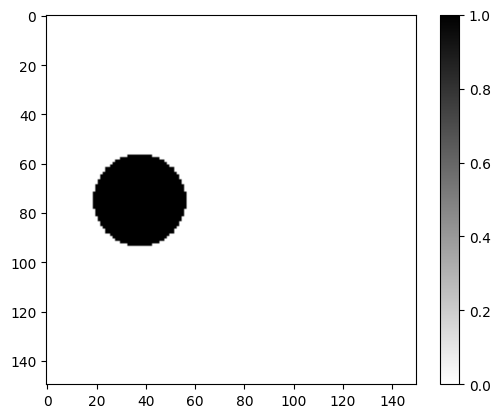

In [23]:
Nx = 150
Ny = 150
X, Y = np.meshgrid(range(Nx), range(Ny))
disk = (X - Nx/4)**2 + (Y - Ny/2)**2 < (Ny/8)**2

plt.imshow(disk, cmap='binary')
plt.colorbar()


In [ ]:
parameters = {
    "tau": 1,
    "body_force": (1e-6, 0),
    "num_steps": 5000,
    "check_convergence": 100,
    "convergence_error": 1e-5,
}
ux, uy = run_lbm(domain=disk, parameters=parameters)
u = np.sqrt(ux**2 + uy**2)


100%|██████████| 1000/1000 [00:20<00:00, 48.82it/s]

Reached maximum iterations


0.031799430387775086


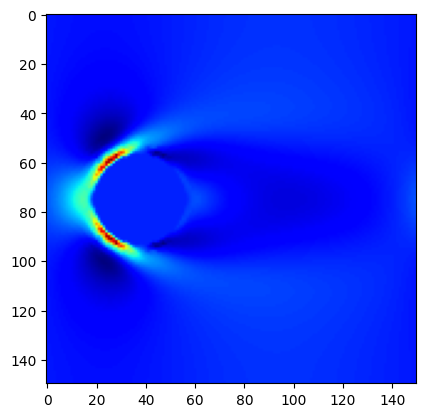

In [ ]:
# TODO: Visualize the velocity field and vorticity

## Calculate Permeability

Once we have the velocity field, we can compute the absolute permeability using Darcy's law:

$$k = \frac{\bar{u} \mu L}{\Delta P}.$$

In lattice units, we can usually replace the pressure gradient with a body force $F$ since $\nabla P \approx \rho F$:

$$ k = \frac{\nu \bar{u}}{F}$$
Keep in mind that the calculated permeability will be in lattice units ($lu^2$). To convert to the true permeability, we would need to know the physical size of our grid sizes.

For sake of simplicity, we can calculate the mean velocity of the flow-direction-component.

In [ ]:
def compute_permeability(ux, parameters: Dict):
  tau = parameters.get('tau', 1.0)
  # TODO: Compute the kinematic viscosity from the relaxation time tau (nu = cs2 * (tau - 0.5))
  cs2 = parameters.get('cs2', 1.0/3.0)  # Speed of sound squared for D2Q9 lattice
  nu =
  # TODO: Compute the mean velocity in the fluid nodes in the flow direction (x-direction)
  u_mean =

  body_force = parameters.get('body_force', (1.0e-4, 0.0))
  b_x = body_force[0]
  # TODO: Compute the permeability (k)
  k =
  return

# Calculate the average velocity for our image
print(f"Computed permeability: {compute_permeability(ux, parameters)}")

Let's use the Porespy library to generate some blobs. Make sure you get a geometry that percolates!

In [ ]:
import porespy as ps
def generate_blobs(phi):
  obstacle = ~ps.generators.blobs(shape=[200, 200], porosity=phi)
  #obstacle = torch.tensor(fromfunction(obstacle_fun(cx,cy,r),(nx, ny)))
  plt.imshow(obstacle, cmap='binary')
  plt.colorbar()
  return obstacle

phi_widget = widgets.FloatSlider(value=0.5, min=0.5, max=0.86, description='Porosity',
                                 continuous_update=False, step=0.01)

blobs = widgets.interactive(generate_blobs, {'manual': True},
                                       phi=phi_widget)

blobs


interactive(children=(FloatSlider(value=0.5, continuous_update=False, description='Porosity', max=0.86, min=0.…

In [ ]:
u_x, u_y = run_lbm(blobs.result)

In [ ]:
# TODO: Visualize the velocity field

In [ ]:
# TODO: Compute the permeability from the flow field